### COMP 333 - Programming Assignment 3

Annika Timermanis

ID: 40131128

**Assignment Description:** wrangle a dataset, create functions to perform similar data wrangling techniques from open refine, including facets, clustering, and trimming whitespaces.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


### Importing Ecological Dataset

In [2]:
df = pd.read_csv('/content/gdrive/My Drive/Colab Notebooks/comp 333 labs/prog_assignments/Portal_rodents_19772002_scinameUUIDs.csv', encoding='windows-1252')
df.head()

/usr/local/lib/python3.7/dist-packages/IPython/core/interactiveshell.py:3326: DtypeWarning: Columns (11,12,13,16,17,18,33,35) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


,survey_id,recordID,mo,dy,yr,period,plot_id,plot,note1,stake,...,tag,note2,ltag,note3,prevrt,prevlet,nestdir,neststk,note4,note5
0,491ec41b-0a80-4ce9-b754-2983c6f38e71,6545,9,18,1982,62.0,4dc16022-f28d-4b9d-9062-c7bc3ad43362,13,13.0,36.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,f280bade-4e9b-447d-afe0-9e6d45e6bfb0,5220,1,24,1982,54.0,dcbbd373-c22e-46ef-ae8b-ad88f5cf7475,20,13.0,27.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2b1b4a8a-c3e9-4781-a5f9-18b081383876,18932,8,7,1991,162.0,1e87b11b-4795-4f41-bdff-2d5c4412be25,19,13.0,33.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,D
3,e98e66c4-514b-45f7-9d95-336c05a72b21,20588,1,24,1993,179.0,91829d58-c12e-47e8-ae31-185f46be21d2,12,13.0,41.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,768cdd0d-93bc-4c74-9dcd-d1ed48b7501e,7020,11,21,1982,63.0,f24f2db6-eadd-4de9-9d2f-95aea376c013,24,13.0,72.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **Number of features in dataset**

In [3]:
print(len(df.columns))

39


In [4]:
print(df.columns)

Index(['survey_id', 'recordID', 'mo', 'dy', 'yr', 'period', 'plot_id', 'plot',
       'note1', 'stake', 'species', 'scientificName', 'locality', 'JSON',
       'decimalLatitude', 'decimalLongitude', 'county', 'state', 'country',
       'sex', 'age', 'reprod', 'testes', 'vagina', 'pregnant', 'nipples',
       'lactation', 'hfl', 'wgt', 'tag', 'note2', 'ltag', 'note3', 'prevrt',
       'prevlet', 'nestdir', 'neststk', 'note4', 'note5'],
      dtype='object')


### **Text Facet**

In [5]:
from pandas.api.types import is_string_dtype
from pandas.api.types import is_numeric_dtype

def text_facet(df, colname):
  if(is_string_dtype(df[colname])):
    unique_value_counts = df[colname].value_counts()
    print(unique_value_counts)

In [6]:
text_facet(df,"scientificName")

Dipodomys merriami                 10596
Dipodomys ordii                     3027
Dipodomys spectabilis               2504
Onychomys torridus                  2249
Onychomys leucogaster               1006
Ammospermophilus harrisi             435
Amphispiza bilineata                 289
Baiomys taylori                       46
Dipodomys sp.                         40
Onychomys sp.                         12
Amphespiza bilineata                   7
Chaetodipus baileyi                    2
Emphispiza bilinata                    2
Ammodramus savannarum                  2
Cnemidophorus uniparens                1
Crotalus viridis                       1
Crotalus scutalatus                    1
  Amphispiza bilineata                 1
Cnemidophorus tigris                   1
  Amphispiza bilineata                 1
Callipepla squamata                    1
Calamospiza melanocorys                1
Amphispizo bilineata                   1
Amphispiza cilineata                   1
Amphispiza bilin

### **Numeric Facet**

In [19]:
def numeric_facet(df, colname, log=False):
  if(is_numeric_dtype(df[colname])):
    title = 'Histogram of ' + colname 
    count, bins = np.histogram(df[colname])
    if(log):
      count = np.log10(count)
      title += ' (log)'
    plt.title(title)
    plt.hist(bins[:-1],bins, weights=count,edgecolor='black',linewidth=1.2)
    plt.show()

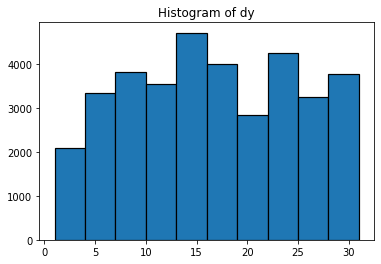

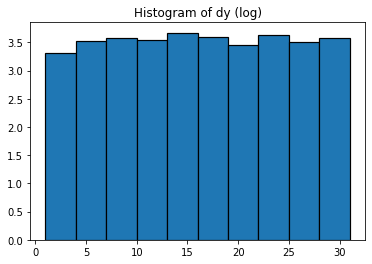

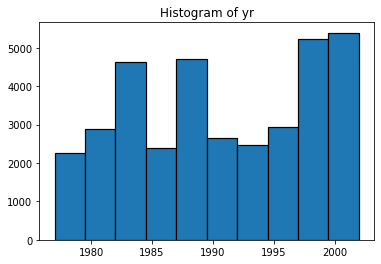

In [20]:
numeric_facet(df,"dy")
numeric_facet(df,"dy", True)
numeric_facet(df,"yr")

### **Cluster a Column of Text Entries**

In [9]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from IPython.display import display

def cluster_text(df, colname):
  if(is_string_dtype(df[colname])):
    vectorizer = TfidfVectorizer(max_df=0.5, min_df=5, stop_words="english")
    X_tfidf = vectorizer.fit_transform(df[colname].values.astype('U'))

    km = KMeans(n_clusters=10, max_iter=100, n_init=5)
    km.fit(X_tfidf)
    
    d = {colname: df[colname]}
    df_cluster = pd.DataFrame(d)
    df_cluster['labels'] = km.labels_

    display(df_cluster.head(10))


In [10]:
cluster_text(df, "scientificName")

,scientificName,labels
0,Amphispiza bilineata,7
1,Amphispiza bilineata,7
2,Ammodramus savannarum,8
3,Ammodramus savannarum,8
4,Ammospermophilis harrisi,6
5,Ammospermophilus harrisi,6
6,Ammospermophilus harrisi,6
7,Ammospermophilus harrisi,6
8,Ammospermophilus harrisi,6
9,Ammospermophilus harrisi,6


### **Trimming all Whitespace at the Start and End of a String**

In [11]:
def trim_whitespace(df, colname):
  if(is_string_dtype(df[colname])):
    trimmed_strings = list(map(lambda x: x.strip() if (type(x) == str) else x, df[colname]))
    df[colname] = pd.Series(trimmed_strings)


In [12]:
test = "  Amphispiza bilineata   "
print(test)
print(test.strip())
print(len(test))
print(len(test.strip()))

  Amphispiza bilineata   
Amphispiza bilineata
25
20


In [13]:
print(df["scientificName"].iloc[0:5].values)

trim_whitespace(df, "scientificName")

print(df["scientificName"].iloc[0:5].values)

['  Amphispiza bilineata' '  Amphispiza bilineata  '
 'Ammodramus savannarum' 'Ammodramus savannarum'
 'Ammospermophilis harrisi']
['Amphispiza bilineata' 'Amphispiza bilineata' 'Ammodramus savannarum'
 'Ammodramus savannarum' 'Ammospermophilis harrisi']


### **Replacing Internal Whitespace by a Single Space**

In [14]:
def replace_whitespace(df, colname):
  if(is_string_dtype(df[colname])):
    single_space = list(map(lambda x: ' '.join(x.split()) if (type(x) == str) else x, df[colname]))
    return single_space


In [15]:
test2 = "Amphispiza   bilineata"
print(test2)
print(len(test2))

test2 = ' '.join(test2.split());
print(test2)
print(len(test2))

Amphispiza   bilineata
22
Amphispiza bilineata
20


In [16]:
print(df["scientificName"].iloc[0:5].values)

replace_whitespace(df, "scientificName")

print(df["scientificName"].iloc[0:5].values)

['Amphispiza bilineata' 'Amphispiza bilineata' 'Ammodramus savannarum'
 'Ammodramus savannarum' 'Ammospermophilis harrisi']
['Amphispiza bilineata' 'Amphispiza bilineata' 'Ammodramus savannarum'
 'Ammodramus savannarum' 'Ammospermophilis harrisi']
